In [1]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np
import pod5
import pickle

from hmmlearn import hmm
from scipy import stats

POD5 = '/mnt/sod2-project/csb4/wgs/metagenomics_data/projects/segmentation/segmentation_data/R10_Zymo_subsample/barcode24_zymo_wo_EC_1k_per_species_min_len_1k/barcode24_zymo_subsampled_wo_EC_min_len_1k.pod5'
alignment_file = '/home/stumaxime/scratch/Campolina/alignments_unet_4L_old_labels_reduced_lr.csv'

In [4]:
# hyper-params for hmm

WINDOW_LEN = 11

PRUNE_LV_MINLENGTH = 20 # lowvar regions should be at least this length 
PRUNE_LV_MAXSTD = 0.2 # lowvar regions should have at most this stdev
PRUNE_HV_MINLEN = 10 # highvar regions that are between 2 lowvar regions and are less than this length should be changed to lowvar regions

## Helper Funcs

In [5]:
def compute_features(signal):
    signal = stats.zscore(signal)
    windows = np.lib.stride_tricks.sliding_window_view(signal, window_shape=WINDOW_LEN)
    w_stds = np.std(windows, axis=-1)
    w_mad = np.median(np.abs(windows - np.median(windows, axis=-1, keepdims=True)), axis=-1)
    return signal, w_stds, w_mad

In [6]:
def prune_state_0(prediction, signal):
    '''
    Prune the low var regions by removing them if they are either too short or have too much variance.
    '''
    changes = np.diff(prediction, prepend=prediction[0])
    
    split_idx = np.where(changes != 0)[0]
    
    segments_pred   = np.split(prediction, split_idx)
    segments_signal = np.split(signal, split_idx)
    
    for i, seg_pred in enumerate(segments_pred):

        seg_signal = segments_signal[i]

        if seg_pred[0] != lvstate: continue

        if len(seg_pred) < PRUNE_LV_MINLENGTH or np.std(seg_signal) > PRUNE_LV_MAXSTD:
            segments_pred[i] = np.full_like(seg_pred, hvstate)

    result = np.concatenate(segments_pred)
    return result

def prune_state_1(prediction):
    '''
    Prune the high var regions that short and are between two low var regions (e.g. one small spike). 
    '''
    changes = np.diff(prediction, prepend=prediction[0])
    split_idx = np.where(changes != 0)[0]    
    segments_pred = np.split(prediction, split_idx)
    
    for i, seg_pred in enumerate(segments_pred):
        
        if (i == 0 or i == (len(segments_pred)-1) or seg_pred[0] == lvstate): continue

        is_short = len(seg_pred) < PRUNE_HV_MINLEN
        is_between_low_var_states = (segments_pred[i-1][0] == lvstate) and (segments_pred[i+1][0] == lvstate)
            
        if is_short and is_between_low_var_states:
            segments_pred[i] = np.full_like(seg_pred, lvstate)

    result = np.concatenate(segments_pred)
    return result

def prune(prediction, signal):
    return prune_state_1(prune_state_0(prediction, signal))

In [7]:
def plot_predictions(signal, preds, nfigs=5):
    inc = 1000
    start = 0
    end = start + inc
    nfig = min(nfigs, len(signal) // inc - 1)

    fig, ax = plt.subplots(nfig, figsize=(20, 3*nfig))

    colors = ['blue', 'red']

    for i in range(nfig):
        x = signal[start:end]
        o = preds[start:end]

        for j in range(len(x) - 1):
            ax[i].plot([j, j + 1], x[j:j+2], color=colors[o[j]])
            ax[i].set_ylim(-2.2, 2.2)
            
        start = end
        end = start + inc

## Training the HMM Model

**Create the dataset of (rolling std, rolling mad).**

In [8]:
def make_hmm_data(pod5_file: str = POD5, nsamples: int = 100):
    assert WINDOW_LEN % 2 == 1
    
    data = []
    lengths = []

    with pod5.Reader(pod5_file) as reader:
        for count, read_record in enumerate(reader):
            if count == nsamples: break

            signal = read_record.signal
            signal, w_stds, w_mad = compute_features(signal)
            
            pad = (WINDOW_LEN - 1) // 2
            w_stds = np.pad(w_stds, (pad, pad), mode='edge')
            w_mad = np.pad(w_mad, (pad, pad), mode='edge')
            
            sample = np.stack([signal, w_stds, w_mad], axis=1)
            
            lengths.append(sample.shape[0])
            data.append(sample)

    return np.vstack(data), np.array(lengths)

data, lens = make_hmm_data(nsamples=200)
data.shape, lens.shape

((18058806, 3), (200,))

**Fit the model to the data.** (Takes some time.)

In [9]:
n_train = 200
data_train = data[:sum(lens[:n_train]), 1:]

model = hmm.GaussianHMM(
    n_components=2,
    n_iter=10,
    random_state=42,
    verbose=True,
)

model.fit(data_train, lengths=lens[:n_train])
print(f'model has converged = {model.monitor_.converged}')

         1 -17252830.65329650             +nan
         2 9877006.94810797 +27129837.60140447
         3 11893882.01361166 +2016875.06550369
         4 18205154.46901122 +6311272.45539957
         5 30152640.87826562 +11947486.40925440
         6 32295348.84667591 +2142707.96841028
         7 32398653.17451901 +103304.32784310
         8 32439363.96885796  +40710.79433895
         9 32460960.56738378  +21596.59852583
        10 32473086.85303920  +12126.28565542
        11 32479943.24555678   +6856.39251757
        12 32483809.33785187   +3866.09229510
        13 32485980.41191468   +2171.07406280
        14 32487195.12818190   +1214.71626722
        15 32487872.79394019    +677.66575829
        16 32488250.03636517    +377.24242498
        17 32488459.71320663    +209.67684146
        18 32488576.12592811    +116.41272148
        19 32488640.70768332     +64.58175521


model has converged = True


        20 32488676.51565208     +35.80796876


**Visualize hidden states distributions.**

In [ ]:
minvar  = float('inf')
lvstate = None

for state in range(model.n_components):
    print(f"state {state}:")
    print("- mean:", model.means_[state])
    print("- covariance:\n", model.covars_[state])
    if model.covars_[state].sum() < minvar:
        lvstate = state
        minvar = model.covars_[state].sum()
    print('----------------------------------------')

hvstate = int(not lvstate)

print(f'Low var state = {lvstate}, High var state = {hvstate}')

In [ ]:
colors = ['blue', 'red']
names  = ['stdev', 'mean abs dev']

nfeatures = data_train.shape[1]

fig, ax = plt.subplots(1, nfeatures, figsize=(10, 3))

for feature in range(nfeatures):

    for state in range(model.n_components):
        mean = model.means_[state]
        cov = model.covars_[state]

        mean_feature = mean[feature]
        std_feature = np.sqrt(cov[feature, feature])

        x = np.linspace(mean_feature - 4*std_feature, mean_feature + 4*std_feature, 100)
        y = 1 / (std_feature * np.sqrt(2*np.pi)) * np.exp(-(x - mean_feature)**2 / (2*std_feature**2))
    
        ax[feature].plot(x, y, color=colors[state], label=('low var state' if state == lvstate else 'high var state'))

    ax[feature].set_xlabel(names[feature])
    ax[feature].set_ylabel("Probability density")
    ax[feature].legend()
        
plt.show()

In [ ]:
a = sum(lens[:1])
b = sum(lens[:2])

sample = data[a:b]
preds  = model.predict(sample[:, 1:])
preds  = prune(preds, sample[:, 0])
plot_predictions(sample[:, 0], preds, 2)

In [ ]:
count_0 = 0
count_1 = 0

for i in range(len(lens)-1):
    a = sum(lens[:i])
    b = sum(lens[:i+1])

    sample = data[a:b]

    features = sample[:, 2:]
    signal = sample[:, 0]
    
    pred = prune(model.predict(features), signal)
    
    changes = np.diff(pred, prepend=pred[0])
    split_idx = np.where(changes != 0)[0]
    
    splits = np.split(pred, split_idx)
    
    for split in splits:
        if split[0] == lvstate: count_0 += len(split)
        else: count_1 += len(split)

print(f'pruned low var regions represent {count_0 / (count_1 + count_0)*100:.0f}% of the data')

In [ ]:
# save the hmm model for reuse
with open('hmm.pkl', 'wb') as file: pickle.dump(model, file)

## Analyzing Alignment Data

In [20]:
# load model
model: hmm.GaussianHMM
with open('hmm.pkl', 'rb') as file: model = pickle.load(file)

minvar  = float('inf')
lvstate = None

for state in range(model.n_components):
    if model.covars_[state].sum() < minvar:
        lvstate = state
        minvar = model.covars_[state].sum()

hvstate = int(not lvstate)

print(f'Low var state = {lvstate}')
print(f'High var state = {hvstate}')

Low var state = 1
High var state = 0


In [21]:
def make_hmm_features(signal):
    signal, w_stds, w_mad = compute_features(signal)
    pad = (WINDOW_LEN - 1) // 2
    w_stds = np.pad(w_stds, (pad, pad), mode='edge')
    w_mad = np.pad(w_mad, (pad, pad), mode='edge')
    sample = np.stack([signal, w_stds, w_mad], axis=1)
    return sample

In [23]:
alignments = pl.read_csv(alignment_file)

dataset =  []

to_take = 100

with pod5.Reader(POD5) as reader:
    for i, read_id in enumerate(alignments['read_id'].unique()[:to_take]):
        #print(i, end=' ')
        read = next(reader.reads(selection=[read_id]))
        signal = read.signal
        dataset.append((read_id, signal))

dataset[0]

('efedb96f-863b-4ae6-ab1b-813451c4245b',
 array([639, 528, 535, ..., 488, 506, 422], shape=(119440,), dtype=int16))

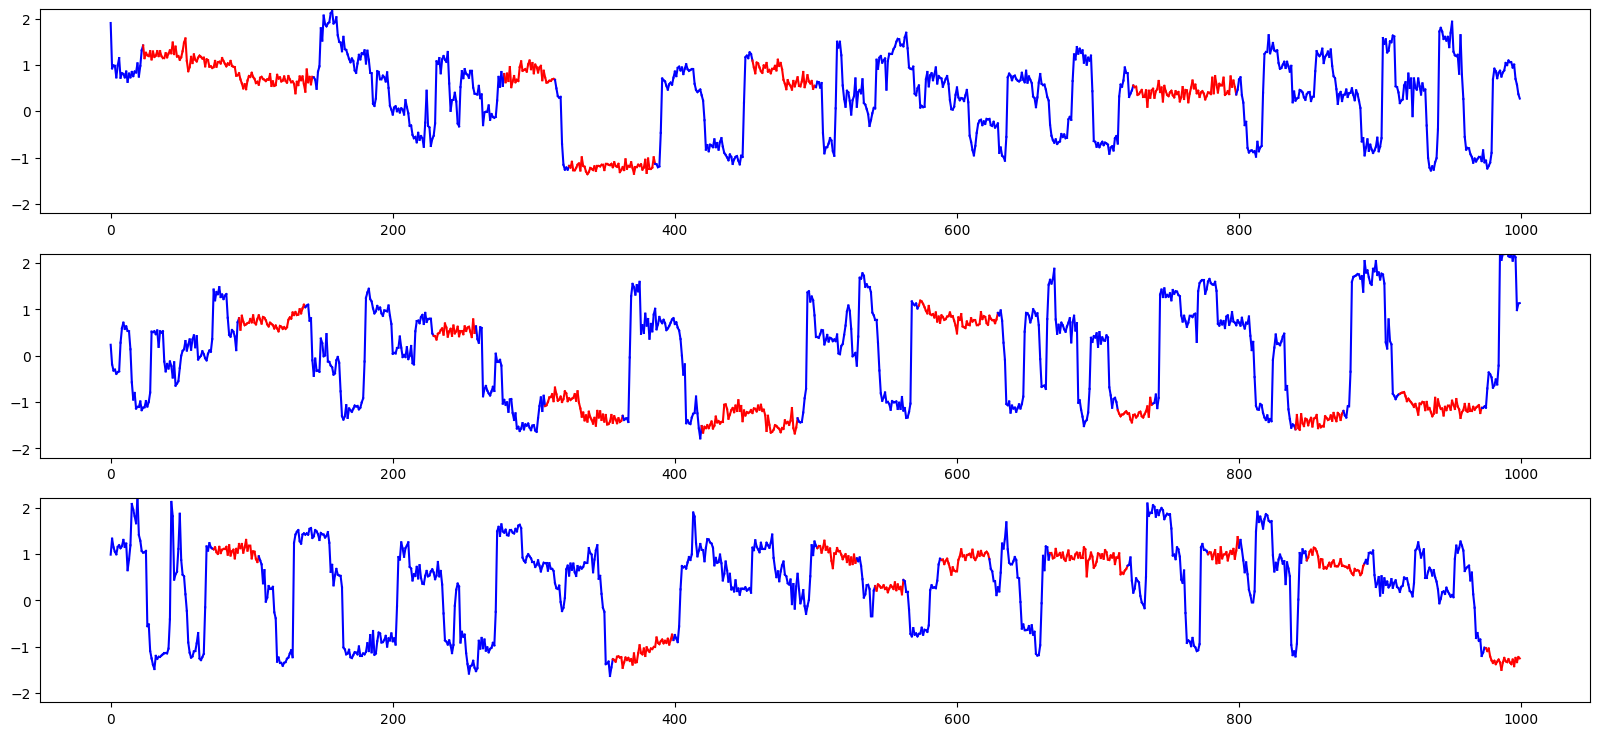

In [24]:
def predict(signal, model=model):
    features  = make_hmm_features(signal)
    hmm_preds = model.predict(features[:, 1:])
    hmm_preds = prune(hmm_preds, features[:, 0])
    return hmm_preds, features

stop = False
i = 0
while not stop: 
    rid, signal = dataset[i]
    preds, features = predict(signal)
    stop = 1 in preds[:3_000]
    i += 1

plot_predictions(features[:, 0], preds, 3)

In [25]:
# assign a unique identifier to each lowvar region
def assign_unique_ids(preds):
    preds  = np.where(preds == hvstate, -1, lvstate)
    mask   = (preds == lvstate)
    starts = mask & (~np.roll(mask, 1, axis=0))
    runs   = np.cumsum(starts)
    labels = runs * mask
    return labels

# compute predictions
base = 0 # for unique ids
predictions = []
for (rid, signal) in dataset:
    preds, _ = predict(signal)
    preds = assign_unique_ids(preds)
    preds[preds > 0] += base
    predictions.append((rid, preds))
    base = max(preds) + 1

predictions[0]

('efedb96f-863b-4ae6-ab1b-813451c4245b',
 array([0, 0, 0, ..., 0, 0, 0], shape=(119440,)))

In [26]:
predictions = {rid: pred for (rid, pred) in predictions}
len(predictions)

100

In [27]:
events = alignments.filter(pl.col('read_id').is_in(predictions.keys()))

# add the hmm state for each predicted event
states = []
for row in events.iter_rows():
    rid = row[-1]
    start, end = row[3]-1, row[4]-1 # a priori 1-indexed
    pred = predictions[rid]
    states.append([pred[start], pred[end]])

states = np.array(states)
states

array([[0, 0],
       [0, 0],
       [0, 0],
       ...,
       [0, 0],
       [0, 0],
       [0, 0]], shape=(722885, 2))

In [28]:
# add hmm states next to predictions
events = events.with_columns(pl.Series('hmm_state_start', states[:, 0]), pl.Series('hmm_state_end',   states[:, 1]))
events.filter(pl.col('hmm_state_start') > 0).head(2)

event_start,event_end,event_mean,remora_start,remora_end,remora_event_mean,ref_kmer_level,ref_kmer,nearest_table_kmer,event_align_status,read_id,hmm_state_start,hmm_state_end
i64,i64,f64,i64,i64,f64,f64,str,str,i64,str,i64,i64
1816,1854,-1.547795,1818,1854,-1.601817,-1.56115,"""CCACGGATA""","""CCAAGGAAC""",0,"""0101ff05-52d3-4af7-bb8b-7bebb9…",15602,0
2379,2404,-1.842984,2400,2404,-1.907094,-1.662222,"""CACTGAAAA""","""AAAACAAAT""",1,"""0101ff05-52d3-4af7-bb8b-7bebb9…",15605,15605


In [29]:
p_event_start_in_lv = events.filter(pl.col('hmm_state_start') > 0).height / events.height
p_event_end_in_lv   = events.filter(pl.col('hmm_state_end') > 0).height   / events.height

print(f'P(event starts in lowvar region) = {p_event_start_in_lv:.3f}')
print(f'P(event ends in lowvar region)   = {p_event_end_in_lv:.3f}')

P(event starts in lowvar region) = 0.103
P(event ends in lowvar region)   = 0.102


In [30]:
events_lowvar_or  = events.filter((pl.col('hmm_state_start') > 0) | (pl.col('hmm_state_end') > 0))
events_lowvar_and = events.filter((pl.col('hmm_state_start') > 0) & (pl.col('hmm_state_start') == pl.col('hmm_state_end')))

p_event_half_in_lowvar  = events_lowvar_or.height / events.height
p_event_fully_in_lowvar = events_lowvar_and.height / events.height

print(f'P(event is starting or ending in lowvar region) = {p_event_half_in_lowvar*100:.2f}%')
print(f'P(event is fully contained (starts and ends) in lowvar region) = {p_event_fully_in_lowvar*100:.2f}%')

P(event is starting or ending in lowvar region) = 15.58%
P(event is fully contained (starts and ends) in lowvar region) = 4.95%


In [31]:
n_errors = events.filter(pl.col('event_align_status') > 0).height
print(f'P(error) = {n_errors / events.height:.2f}')

n_errors_or = events_lowvar_or.filter(pl.col('event_align_status') > 0).height

print(f'P(error | event is in lv region) = {n_errors_or / events_lowvar_or.height:.2f}')

print(f'P(event is in lowvar region | error) = {n_errors_or / n_errors:.2f} given that lv events represent {p_event_half_in_lowvar*100:.0f}% of the data')

P(error) = 0.35
P(error | event is in lv region) = 0.60
P(event is in lowvar region | error) = 0.27 given that lv events represent 16% of the data


In [32]:
events_start_in_lowvar = events.filter((pl.col('hmm_state_start') > 0))
events_start_and_end_in_lowvar = events.filter((pl.col('hmm_state_start') > 0) & (pl.col('hmm_state_start') == pl.col('hmm_state_end')))

avg_start_lowvar = events_start_in_lowvar['hmm_state_start'].value_counts().mean()['count']
print(f'average number of events that start in lowvar regions (per unique region) is {avg_start_lowvar[0]:.2f}')

avg_start_and_end_lowvar = events_start_and_end_in_lowvar['hmm_state_start'].value_counts().mean()['count']
print(f'average number of events that are fully in lowvar regions (per unique region) is {avg_start_and_end_lowvar[0]:.2f}')

average number of events that start in lowvar regions (per unique region) is 2.29
average number of events that are fully in lowvar regions (per unique region) is 2.19


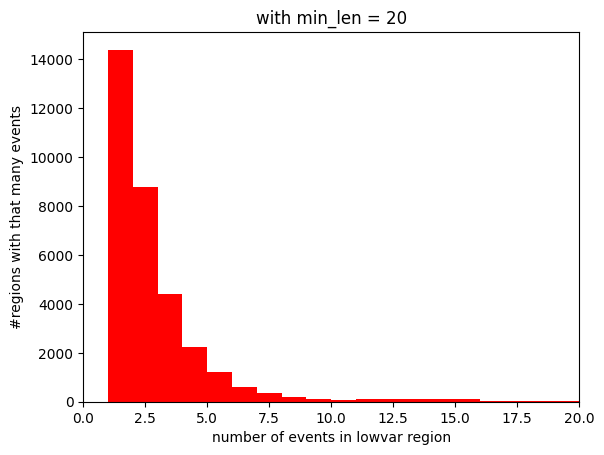

In [33]:
lowvar_regions = events.filter(pl.col('hmm_state_start') > 0).group_by('hmm_state_start').len()
bins = np.concatenate([np.arange(0, 11, 1), np.arange(11, max(lowvar_regions['len'])+5, 5)])
plt.hist(lowvar_regions['len'], bins=bins, color='red')
plt.xlim(0, 20)
plt.xlabel('number of events in lowvar region')
plt.ylabel('#regions with that many events')
plt.title(f'with min_len = {PRUNE_LV_MINLENGTH}')
plt.show()

In [34]:
ratio = lowvar_regions.filter(pl.col('len') == 1).height / lowvar_regions.height
print(f'ratio of lv regions containing a single event / all lv regions = {ratio}')

ratio of lv regions containing a single event / all lv regions = 0.44110436967579825
